In [90]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [91]:
N=100000
nt = 50
STEP = 500

In [92]:
STEP = 0

# Allora, non dovrei fare così dovrei passarle alal funzione
# però mi scoccio ormai ho fatto cosi e ridefinisco in ogni foglio.
x1 = 0
y2 = 0
x2 = 0
y1 = 0
M1 = 0
M2 = 0

G = 6.674e-11 

def g(state,t):
    x, vx, y, vy = state[0], state[1], state[2], state[3] 
    r1 = ((x-x1)**2 + (y-y1)**2)**(1.5)
    r2 = ((x-x2)**2 + (y-y2)**2)**(1.5)

    v = np.zeros(4)
    v[0] = vx
    v[1] = -G*M1*(x-x1)/(r1) - G*M2*(x-x2)/(r2)
    v[2] = vy
    v[3] = -G*M1*(y-y1)/(r1) - G*M2*(y-y2)/(r2)
    return v

def rungeKutta(y, t, dt):
    C1 = g(y, t)
    C2 = g(y + dt*C1/2, t + dt/2)
    C3 = g(y + dt*C2/2, t + dt/2)
    C4 = g(y + dt*C3,   t + dt)
    return y + dt*(C1 + 2*C2 + 2*C3 + C4)/6

def esperimento(Y0,DT):
    Y = Y0.copy()
    
    X1 = np.zeros(N+1)
    Y1 = np.zeros(N+1)
    X1[0] = Y[0]
    Y1[0] = Y[2]

    for i in range(N):
        t = DT*i
        Y = rungeKutta(Y,t,DT + STEP)
        X1[i+1] = Y[0]
        Y1[i+1] = Y[2]
    
    return X1,Y1

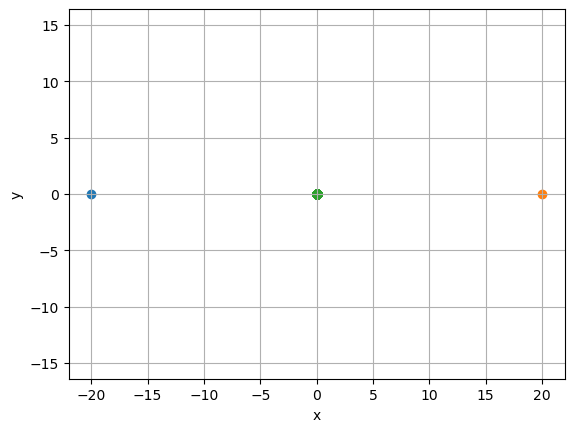

In [95]:

# equilibrio (veosimilmente instabile)
x1 = -20
y2 = 00
x2 = 20
y1 = 0
M1 = 10000
M2 = M1
STEP = 100

Y0 = np.array([0, 0.0, 0.0,0])
DT = 3*math.pi/nt
X, Y = esperimento(Y0, DT)
plt.scatter(x1,y1)
plt.scatter(x2,y2)
plt.scatter(X, Y)
plt.axis('equal')                     # importante per vedere l'orbita senza distorsioni
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

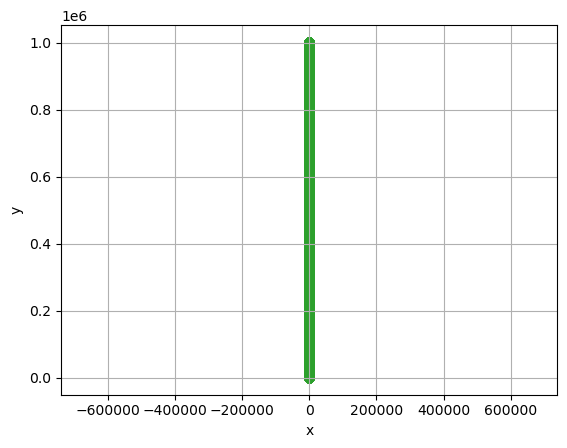

In [97]:

# equilibrio (veosimilmente instabile)
x1 = -20
y2 = 00
x2 = 20
y1 = 0
M1 = 10000
M2 = M1*0.01
STEP = 100

Y0 = np.array([0, 0.0, 0.0,0.1])
DT = 3*math.pi/nt
X, Y = esperimento(Y0, DT)
plt.scatter(x1,y1)
plt.scatter(x2,y2)
plt.scatter(X, Y)
plt.axis('equal')                     # importante per vedere l'orbita senza distorsioni
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()